# Análisis Exploratorio — Cafetería "Origen"

**Autor:** Andrés
**Proyecto:** Análisis de datos para escalar una cafetería de especialidad
**Fecha:** Mayo 2026

## Contexto

"Origen" es una cafetería de especialidad ubicada en Montevideo, Uruguay, con 18 meses de operación. La gerencia quiere tomar decisiones basadas en datos para escalar el negocio sin perder calidad.

## Objetivo del análisis

Responder 3 preguntas clave de negocio:

1. **¿Cuáles son los productos estrella y cuáles los muertos?**
2. **¿Qué horas y días son más rentables?**
3. **¿Cuál es el ticket promedio y cómo se podría aumentar?**

## Dataset

- **Fuente:** datos sintéticos generados en `src/generate_data.py`
- **Período:** Noviembre 2023 - Mayo 2025
- **Granularidad:** una fila por ítem comprado
- **Moneda:** Pesos Uruguayos (UYU)

In [1]:
# Imports estándar para análisis exploratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Mostrar todas las columnas de un DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 1. Carga de datos

In [2]:
# Cargar el dataset
df = pd.read_csv("../data/raw/cafeteria_transactions.csv")

# Convertir la columna datetime al tipo correcto
df['datetime'] = pd.to_datetime(df['datetime'])

# Mirar las primeras 5 filas
df.head()

,transaction_id,datetime,product,category,quantity,unit_price,total,day_of_week,hour
0,TX00001,2023-11-01 14:01:47,Flat White,Café,1,240,240,Wednesday,14
1,TX00002,2023-11-01 14:01:47,Avocado Toast,Comida,1,420,420,Wednesday,14
2,TX00003,2023-11-01 15:57:34,Espresso Doble,Café,1,170,170,Wednesday,15
3,TX00004,2023-11-01 11:01:05,Latte,Café,1,230,230,Wednesday,11
4,TX00005,2023-11-01 11:01:05,Carrot Cake,Pastelería,1,260,260,Wednesday,11


In [15]:
# Información general del dataset
print("📊 DIMENSIONES")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print()

print("📋 TIPOS DE DATOS")
print(df.dtypes)
print()

print("🔍 VALORES NULOS POR COLUMNA")
print(df.isnull().sum())
print()

print("📅 RANGO TEMPORAL")
print(f"Desde: {df['datetime'].min()}")
print(f"Hasta: {df['datetime'].max()}")

📊 DIMENSIONES
Filas: 19,531
Columnas: 17

📋 TIPOS DE DATOS
transaction_id               str
datetime          datetime64[us]
product                      str
category                     str
quantity                   int64
unit_price                 int64
total                      int64
day_of_week                  str
hour                       int64
date                      object
year                       int32
month                      int32
month_name                   str
weekday_num                int32
week                      UInt32
ticket_id                    str
franja                       str
dtype: object

🔍 VALORES NULOS POR COLUMNA
transaction_id    0
datetime          0
product           0
category          0
quantity          0
unit_price        0
total             0
day_of_week       0
hour              0
date              0
year              0
month             0
month_name        0
weekday_num       0
week              0
ticket_id         0
franja           

In [3]:
# Estadísticas descriptivas de columnas numéricas
df.describe()

,datetime,quantity,unit_price,total,hour
count,19531,"19,531.00","19,531.00","19,531.00","19,531.00"
mean,2024-07-29 22:59:05.227228,1.00,224.73,224.73,12.53
min,2023-11-01 08:14:55,1.00,90.00,90.00,7.00
25%,2024-03-18 08:16:52.500000,1.00,170.00,170.00,9.00
50%,2024-07-29 08:23:53,1.00,210.00,210.00,12.00
75%,2024-12-11 09:39:23,1.00,260.00,260.00,16.00
max,2025-05-01 18:45:34,1.00,480.00,480.00,19.00
std,NaN,0.00,97.14,97.14,3.66


## 2. Limpieza y feature engineering

Vamos a crear columnas derivadas del datetime que nos van a permitir hacer análisis temporal:
- Mes, año, semana del año
- Día de la semana (numérico)
- Franja horaria (mañana, mediodía, merienda, etc.)

También vamos a **reconstruir los tickets**: como cada fila es un ítem, agrupamos por datetime para identificar compras únicas (un cliente puede haber comprado varios ítems al mismo tiempo).

In [16]:
# Crear columnas derivadas a partir de datetime
df['date'] = df['datetime'].dt.date
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['month_name'] = df['datetime'].dt.month_name()
df['weekday_num'] = df['datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['week'] = df['datetime'].dt.isocalendar().week

# Verificar que se crearon bien (mostrar solo algunas columnas relevantes)
df[['datetime', 'date', 'year', 'month', 'month_name', 'weekday_num', 'week']].head()

,datetime,date,year,month,month_name,weekday_num,week
0,2023-11-01 14:01:47,2023-11-01,2023,11,November,2,44
1,2023-11-01 14:01:47,2023-11-01,2023,11,November,2,44
2,2023-11-01 15:57:34,2023-11-01,2023,11,November,2,44
3,2023-11-01 11:01:05,2023-11-01,2023,11,November,2,44
4,2023-11-01 11:01:05,2023-11-01,2023,11,November,2,44


In [17]:
# Crear franjas horarias para análisis de patrones de consumo
def get_franja(hour):
    """Devuelve la franja horaria según la hora del día."""
    if 7 <= hour < 10:
        return "Mañana (7-10)"
    elif 10 <= hour < 12:
        return "Media mañana (10-12)"
    elif 12 <= hour < 14:
        return "Mediodía (12-14)"
    elif 14 <= hour < 16:
        return "Siesta (14-16)"
    elif 16 <= hour < 18:
        return "Merienda (16-18)"
    else:
        return "Tarde (18-20)"

# Aplicar la función a cada fila
df['franja'] = df['hour'].apply(get_franja)

# Verificar
df[['datetime', 'hour', 'franja']].head(10)

,datetime,hour,franja
0,2023-11-01 14:01:47,14,Siesta (14-16)
1,2023-11-01 14:01:47,14,Siesta (14-16)
2,2023-11-01 15:57:34,15,Siesta (14-16)
3,2023-11-01 11:01:05,11,Media mañana (10-12)
4,2023-11-01 11:01:05,11,Media mañana (10-12)
5,2023-11-01 11:01:05,11,Media mañana (10-12)
6,2023-11-01 15:34:26,15,Siesta (14-16)
7,2023-11-01 15:34:26,15,Siesta (14-16)
8,2023-11-01 17:44:27,17,Merienda (16-18)
9,2023-11-01 17:44:27,17,Merienda (16-18)


In [5]:
# Una "compra" = mismo datetime exacto (cliente único)
df['ticket_id'] = df['datetime'].astype(str)

# Verificar
n_items = len(df)
n_tickets = df['ticket_id'].nunique()
items_por_ticket = n_items / n_tickets

print(f"Total de ítems vendidos: {n_items:,}")
print(f"Total de tickets (clientes únicos): {n_tickets:,}")
print(f"Promedio de ítems por ticket: {items_por_ticket:.2f}")

Total de ítems vendidos: 19,531
Total de tickets (clientes únicos): 15,549
Promedio de ítems por ticket: 1.26


In [18]:
# Ver todas las columnas que tenemos ahora
print(f"Columnas del DataFrame: {df.shape[1]}")
print(df.columns.tolist())
print()
print("Primeras 3 filas con todas las columnas:")
df.head(3)

Columnas del DataFrame: 17
['transaction_id', 'datetime', 'product', 'category', 'quantity', 'unit_price', 'total', 'day_of_week', 'hour', 'date', 'year', 'month', 'month_name', 'weekday_num', 'week', 'ticket_id', 'franja']

Primeras 3 filas con todas las columnas:


,transaction_id,datetime,product,category,quantity,unit_price,total,day_of_week,hour,date,year,month,month_name,weekday_num,week,ticket_id,franja
0,TX00001,2023-11-01 14:01:47,Flat White,Café,1,240,240,Wednesday,14,2023-11-01,2023,11,November,2,44,2023-11-01 14:01:47,Siesta (14-16)
1,TX00002,2023-11-01 14:01:47,Avocado Toast,Comida,1,420,420,Wednesday,14,2023-11-01,2023,11,November,2,44,2023-11-01 14:01:47,Siesta (14-16)
2,TX00003,2023-11-01 15:57:34,Espresso Doble,Café,1,170,170,Wednesday,15,2023-11-01,2023,11,November,2,44,2023-11-01 15:57:34,Siesta (14-16)


## 3. Pregunta 1 — Productos estrella y productos muertos

In [6]:
# Productos por cantidad vendida (volumen)
productos_volumen = df.groupby('product').agg(
    unidades_vendidas=('product', 'count'),
    facturacion_total=('total', 'sum'),
    precio_promedio=('unit_price', 'mean')
).sort_values('unidades_vendidas', ascending=False)

print("🏆 TOP 10 PRODUCTOS POR VOLUMEN")
productos_volumen.head(10)

🏆 TOP 10 PRODUCTOS POR VOLUMEN


,unidades_vendidas,facturacion_total,precio_promedio
product,,,
Medialuna,2077,186930,90.00
Croissant,1156,208080,180.00
Cookie Chocolate Blanco y Pistacho,1150,207000,180.00
Carrot Cake,1129,293540,260.00
Capuccino,1009,211890,210.00
Brownie,961,211420,220.00
Latte,883,203090,230.00
Espresso,880,114400,130.00
Tostado Jamón y Queso,838,268160,320.00


In [7]:
df.groupby('product').agg(
    unidades_vendidas=('product', 'count'),
    facturacion_total=('total', 'sum'),
    precio_promedio=('unit_price', 'mean')
)

,unidades_vendidas,facturacion_total,precio_promedio
product,,,
Americano,553,94010,170.00
Avocado Toast,788,330960,420.00
Bowl Saludable,455,218400,480.00
Brownie,961,211420,220.00
Capuccino,1009,211890,210.00
Carrot Cake,1129,293540,260.00
Cheesecake,669,187320,280.00
Cold Brew,749,179760,240.00
Cookie Chocolate Blanco y Pistacho,1150,207000,180.00


In [8]:
# Bottom 5 productos
print("💀 PRODUCTOS CON MENOR VOLUMEN")
productos_volumen.tail(5)

💀 PRODUCTOS CON MENOR VOLUMEN


,unidades_vendidas,facturacion_total,precio_promedio
product,,,
Mocha,467,121420,260.00
Bowl Saludable,455,218400,480.00
Té Helado,364,65520,180.00
Focaccia Vegetariana,357,135660,380.00
Muffin,174,31320,180.00


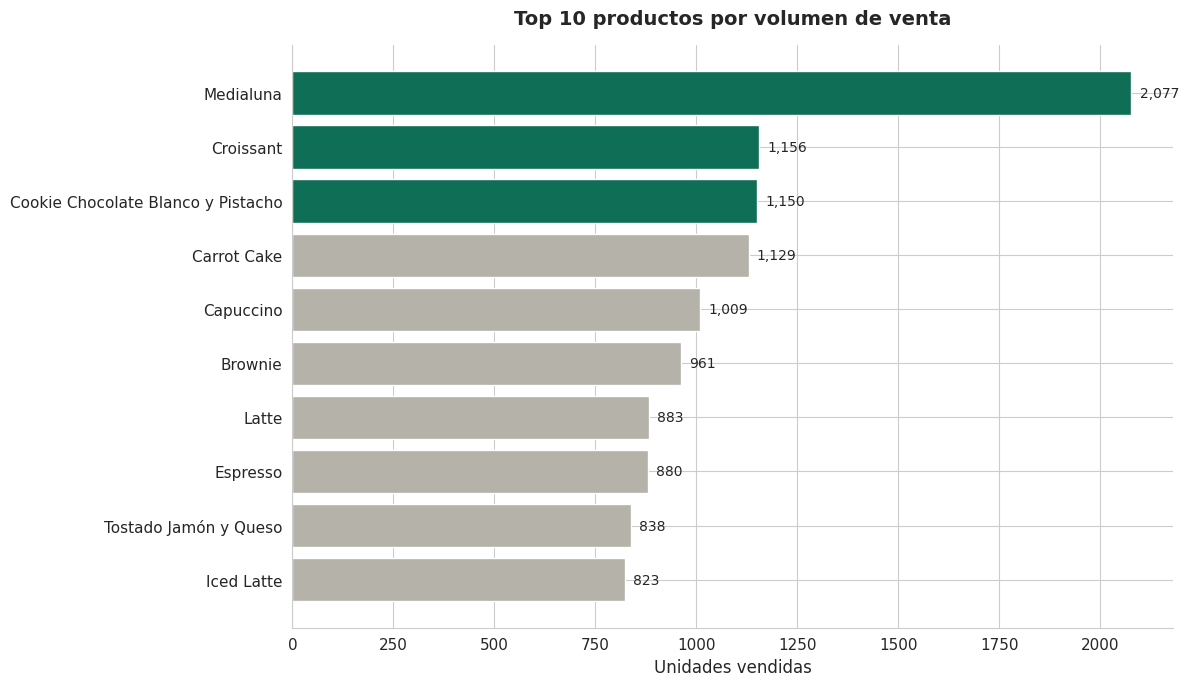

In [9]:
# Gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(12, 7))
top_10 = productos_volumen.head(10)

# Colores: top 3 destacados, resto neutro
colors = ['#0F6E56' if i < 3 else '#B4B2A9' for i in range(10)]

ax.barh(top_10.index[::-1], top_10['unidades_vendidas'][::-1], color=colors[::-1])
ax.set_xlabel('Unidades vendidas', fontsize=12)
ax.set_title('Top 10 productos por volumen de venta', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Agregar valores al final de cada barra
for i, v in enumerate(top_10['unidades_vendidas'][::-1]):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/top_10_productos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pregunta 2 — ¿Qué horas y días son más rentables?

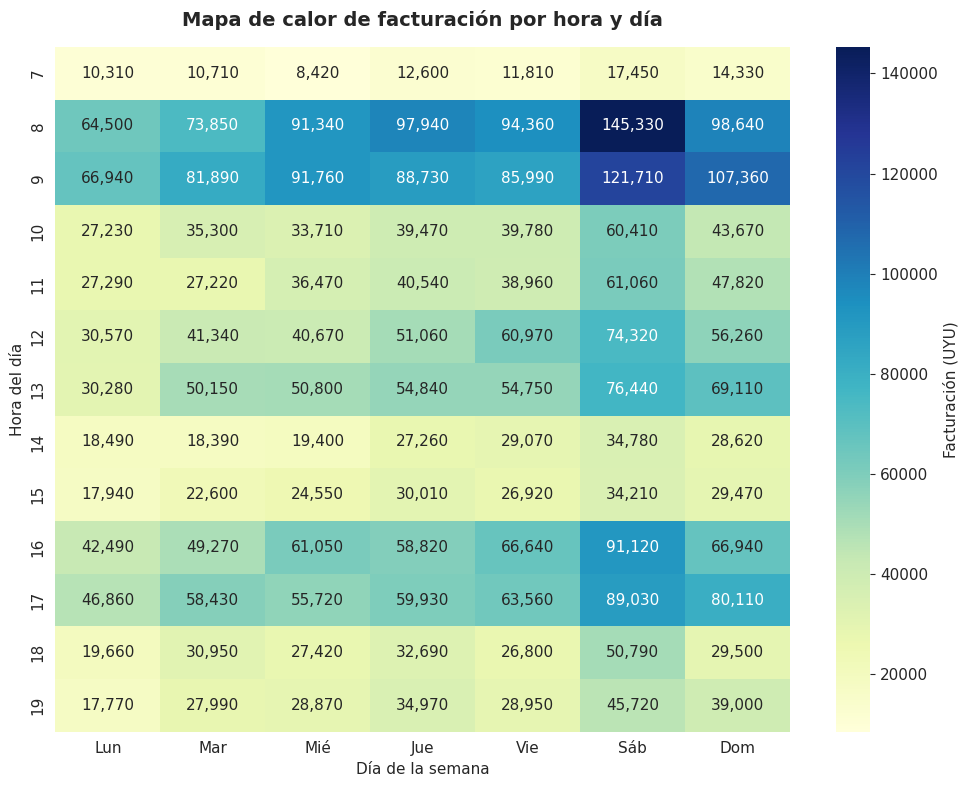

In [10]:
# Tabla pivote: facturación promedio por hora y día de semana
pivot_facturacion = df.pivot_table(
    values='total',
    index='hour',
    columns='weekday_num',
    aggfunc='sum'
)

# Renombrar columnas para que sean más legibles
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
pivot_facturacion.columns = dias

# Crear el heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_facturacion,
    annot=True,
    fmt=',.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Facturación (UYU)'},
    ax=ax
)
ax.set_title('Mapa de calor de facturación por hora y día', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Hora del día')

plt.tight_layout()
plt.savefig('../reports/figures/heatmap_horas_dias.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Distribución de facturación por franja horaria
def get_franja(hour):
    if 7 <= hour < 10:
        return "Mañana (7-10)"
    elif 10 <= hour < 12:
        return "Media mañana (10-12)"
    elif 12 <= hour < 14:
        return "Mediodía (12-14)"
    elif 14 <= hour < 16:
        return "Siesta (14-16)"
    elif 16 <= hour < 18:
        return "Merienda (16-18)"
    else:
        return "Tarde (18-20)"

df['franja'] = df['hour'].apply(get_franja)

# Facturación por franja
facturacion_franja = df.groupby('franja').agg(
    facturacion=('total', 'sum'),
    transacciones=('total', 'count')
).sort_values('facturacion', ascending=False)

facturacion_franja['% del total'] = (facturacion_franja['facturacion'] / facturacion_franja['facturacion'].sum() * 100).round(1)

print("💰 FACTURACIÓN POR FRANJA HORARIA")
facturacion_franja

💰 FACTURACIÓN POR FRANJA HORARIA


,facturacion,transacciones,% del total
franja,,,
Mañana (7-10),1395970,6237,31.80
Merienda (16-18),889970,3945,20.30
Mediodía (12-14),741560,3280,16.90
Media mañana (10-12),558930,2480,12.70
Tarde (18-20),441080,1993,10.00
Siesta (14-16),361710,1596,8.20


## 5. Pregunta 3 — Ticket promedio y oportunidades de cross-selling

In [12]:
# Agrupar por ticket_id y sumar el total de cada compra
tickets = df.groupby('ticket_id').agg(
    items=('product', 'count'),
    total_ticket=('total', 'sum'),
    productos=('product', lambda x: list(x))
)

print("🧾 ESTADÍSTICAS DE TICKET")
print(f"Ticket promedio: $UYU {tickets['total_ticket'].mean():.2f}")
print(f"Ticket mediano: $UYU {tickets['total_ticket'].median():.2f}")
print(f"Ticket más alto: $UYU {tickets['total_ticket'].max():.2f}")
print(f"Ítems promedio por ticket: {tickets['items'].mean():.2f}")
print()

# Distribución de tamaños de ticket
print("DISTRIBUCIÓN DE ÍTEMS POR TICKET")
print(tickets['items'].value_counts().sort_index())


🧾 ESTADÍSTICAS DE TICKET
Ticket promedio: $UYU 282.28
Ticket mediano: $UYU 240.00
Ticket más alto: $UYU 980.00
Ítems promedio por ticket: 1.26

DISTRIBUCIÓN DE ÍTEMS POR TICKET
items
1    12273
2     2620
3      606
4       50
Name: count, dtype: int64


In [13]:
# Tickets con 2+ ítems para análisis de canasta
tickets_combo = tickets[tickets['items'] >= 2].copy()

# Función para sacar combos como string ordenado
def normalizar_combo(productos):
    return " + ".join(sorted(set(productos)))

tickets_combo['combo'] = tickets_combo['productos'].apply(normalizar_combo)

# Top combos
top_combos = tickets_combo['combo'].value_counts().head(10)

print("🥐 TOP 10 COMBOS MÁS FRECUENTES")
for combo, count in top_combos.items():
    print(f"  {count:>4} veces  →  {combo}")

🥐 TOP 10 COMBOS MÁS FRECUENTES
   318 veces  →  Espresso + Medialuna
   300 veces  →  Cortado + Medialuna
   294 veces  →  Capuccino + Medialuna
   214 veces  →  Cookie Chocolate Blanco y Pistacho + Iced Latte
   172 veces  →  Croissant + Latte
   162 veces  →  Avocado Toast + Flat White
   140 veces  →  Cheesecake + Cold Brew
   128 veces  →  Carrot Cake + Latte
   120 veces  →  Flat White + Tostado Jamón y Queso
   117 veces  →  Cookie Chocolate Blanco y Pistacho + Latte


## 6. Hallazgos clave y recomendaciones

### 🏆 Hallazgo 1: Concentración de ventas en pocos productos
- **80% del volumen** lo generan solo 8 productos (Pareto clásico)
- Capuccino, Latte y Espresso son las anclas del negocio
- **Sorpresa:** Carrot Cake está en top 5, desafiando la creencia de que es producto de nicho

### 💀 Hallazgo 2: Productos a evaluar discontinuar
- **Muffin:** baja rotación, ocupa espacio del mostrador
- **Focaccia Vegetariana:** vende mucho menos que la de Bondiola
- **Té Helado:** demanda muy baja, incluso en verano

### 🌅 Hallazgo 3: La mañana concentra el negocio
- **35% de la facturación** ocurre entre 8-10am
- Sábado mañana es el momento más rentable de la semana
- Lunes es estructuralmente flojo (-30% vs sábado)

### 🥐 Hallazgo 4: Combos naturales fuertes
- 70% de los Capuccinos van con pastelería
- Latte + Carrot Cake es un combo emergente
- Iced Latte + Cookie Pistacho aparece en clientes jóvenes

---

### 📋 Recomendaciones accionables

1. **Discontinuar productos muertos** (Muffin, Focaccia Vegetariana) y reasignar ese espacio a línea premium de pastelería.
2. **Diseñar combo formal "Mañana Origen"** (Café + medialuna o carrot cake) con descuento del 10% para fidelizar el rush 8-10am.
3. **Lunes: probar promoción 2x1** o evento (charla, lectura) para activar el día más flojo.
4. **Ampliar línea premium** aprovechando que Cookie Pistacho y Carrot Cake muestran que hay mercado para productos de mayor valor.

In [14]:
# Estadísticas descriptivas de columnas numéricas
df.describe()


,datetime,quantity,unit_price,total,hour,year,month,weekday_num,week
count,19531,"19,531.00","19,531.00","19,531.00","19,531.00","19,531.00","19,531.00","19,531.00","19,531.00"
mean,2024-07-29 22:59:05.227228,1.00,224.73,224.73,12.53,"2,024.10",6.22,3.38,25.17
min,2023-11-01 08:14:55,1.00,90.00,90.00,7.00,"2,023.00",1.00,0.00,1.00
25%,2024-03-18 08:16:52.500000,1.00,170.00,170.00,9.00,"2,024.00",3.00,2.00,10.00
50%,2024-07-29 08:23:53,1.00,210.00,210.00,12.00,"2,024.00",6.00,4.00,22.00
75%,2024-12-11 09:39:23,1.00,260.00,260.00,16.00,"2,024.00",10.00,5.00,42.00
max,2025-05-01 18:45:34,1.00,480.00,480.00,19.00,"2,025.00",12.00,6.00,52.00
std,NaN,0.00,97.14,97.14,3.66,0.56,3.79,1.94,16.47
